In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib_venn
from tabulate import tabulate

# new helper script module that incorporates pandas read-in and adding/separating fields
import parsing_utils as parse

# Summary

Yesterday, I showed Peter the preliminary results of the HG002 spike-in to 894 simulation. We both agreed on the following next steps:
* For all outputs from `sniffles`, exclude centromeric + telomeric (and maybe peri-*) regions at this point of the simulation assessment: many of the SVs called here may be spurious or otherwise outliers that are difficult to parse due to highly repetitive content.
* Use a merging tool that accounts for some shifted differents in SV call position: relying on `REF`/`ALT` identity may exclude mosaic calls that don't match the germline consensus call. 
    * Examine the non-germline variant supporting calls (as in, not in `intersect`): are those reads supporting a *different* variant in `germline`?
* SV size should be evaluated at each step of the filtering/discerning process – what distribution are "true" mosaic (well, simulated) SVs falling under, versus spurious (false positive) SVs?
    * Compare the size distribution of "mosaic" (simulated) SVs derived from HG002 versus "standard" (germline mode called) SVs derived from HG002: this tells us about whether or not we can use size as an exclusion criteria for tuning accuracy of ultra-low frequency SV calls.
    * Break down size distribution of SVs and the # of reads supporting the SV call in both mosaic and standard mode.
* Compare `HG002` recall of `sniffles` standard (germline) calls to the benchmark set.
    * The `sniffles` germline callset will overlap with the benchmark set, and the mosaic callset is likely a subset of the germline callset.
    * For false calls, examine size, type, region, etc... – all useful information for tuning ultra-low frequency calls.
* Calculate the expected SV support reads yielded by sampling ~1X of HG002.

# Loading in data

In [2]:
# HG002 + 894 mosaic call simulation vcf, parsed into a pandas-friendly dataframe
# renamed to 'simulation_0823' just to make things more intuitive
# remember that the filter was DV == 1, 30 <= DR <= 70, QUAL >= 50
simulation_0823 = pd.read_csv('../20230823/filtered.csv')

# HG002 germline call vcf, parsed into a pandas-friendly dataframe
germline_0823 = pd.read_csv('../20230823/germline.csv.gz')

# last week's intersect file: intersected variants called in simulation_0823 (mosaic) vs germline by CHROM, REF, ALT, and SVTYPE
# needs to be iterated with a better merge, uploading for reference
intersect_0823 = pd.read_csv('../20230823/intersect.csv')


# More analysis
## Size distributions
Might as well crank out the low-hanging fruit today :) Files below were copied over from last week's notebook output folder.

In [3]:
# add in chromEnd field that gives the end position of the SV (extracted from info field)
# the POS field is currently equivalent to the chromStart field of a bedfile
# parse below for max compatibility

simulation_0823.rename(columns = {'POS': 'chromStart'}, inplace = True)
germline_0823.rename(columns = {'POS': 'chromStart'}, inplace = True)

simulation_0823['chromStart'] = simulation_0823['chromStart'].astype('float')
germline_0823['chromStart'] = germline_0823['chromStart'].astype('float')
simulation_0823['chromEnd'] = simulation_0823['INFO'].str.extract("(?<=END=)(\w+)(?=;)").astype('float')
germline_0823['chromEnd'] = germline_0823['INFO'].str.extract("(?<=END=)(\w+)(?=;)").astype('float')

# also add SVLEN field, extracted from INFO as well

simulation_0823['SVLEN'] = simulation_0823['INFO'].str.extract("(?<=SVLEN=)(.+)(?=;END)").astype('float')
germline_0823['SVLEN'] = germline_0823['INFO'].str.extract("(?<=SVLEN=)(.+)(?=;END)").astype('float')

column_order = ['#CHROM', 'chromStart', 'chromEnd', 'SVTYPE', 'SVLEN', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO', 'RNAMES', 'GT', 'GQ', 'DR', 'DV']

simulation_0823 = simulation_0823[column_order]
germline_0823 = germline_0823[column_order]

In [4]:
# early early examination of size distribution
print('Max:', simulation_0823['SVLEN'].max())
print('Min:', simulation_0823['SVLEN'].min())
print('Mean:', np.nanmean(simulation_0823['SVLEN']))
print('Standard deviation:', np.nanstd(simulation_0823['SVLEN']))
print('Median:', np.nanmedian(simulation_0823['SVLEN']))


Max: 213647998.0
Min: -164587816.0
Mean: 127398.53353867214
Standard deviation: 10667629.329853574
Median: -65.0


At this point, I realized we have a problem with regards to `SVLEN`. This should *definitely* be a screening category. Just look at these `SVLEN` top/bottom values!!!

This might be fixed by taking out censat regions.

In [5]:
simulation_0823.sort_values('SVLEN', ascending = False)

,#CHROM,chromStart,chromEnd,SVTYPE,SVLEN,ID,REF,ALT,QUAL,FILTER,INFO,RNAMES,GT,GQ,DR,DV
49,chr1,10386828.0,224034826.0,DUP,213647998.0,Sniffles2.DUP.3EEBS0,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=213647998;END=...,894/12784614/ccs,0/0,60,40,1
221,chr1,74801002.0,219541809.0,DUP,144740807.0,Sniffles2.DUP.3F24S0,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=144740807;END=...,894/19141818/ccs,0/0,60,52,1
812,chr2,18200144.0,162689221.0,DUP,144489077.0,Sniffles2.DUP.19AES1,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=144489077;END=...,894/208210773/ccs,0/0,60,58,1
1993,chr4,36674635.0,179960863.0,DUP,143286228.0,Sniffles2.DUP.1629S3,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=143286228;END=...,894/62456170/ccs,0/0,60,52,1
772,chr2,4194444.0,147159914.0,DUP,142965470.0,Sniffles2.DUP.199BS1,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=142965470;END=...,894/221907333/ccs,0/0,60,60,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1487,chr3,36677206.0,186046338.0,DEL,-149369132.0,Sniffles2.DEL.174AS2,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-149369132;END...,894/90505513/ccs,0/0,60,56,1
244,chr1,81289493.0,232975428.0,DEL,-151685935.0,Sniffles2.DEL.3DC7S0,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-151685935;END...,894/251462649/ccs,0/0,60,53,1
855,chr2,32799454.0,197387270.0,DEL,-164587816.0,Sniffles2.DEL.1767S1,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-164587816;END...,894/16321412/ccs,0/0,60,51,1
3155,chr6,104254218.0,NaN,BND,NaN,Sniffles2.BND.1FE3S5,N,[chr9:144166763[N,60,PASS,PRECISE;MOSAIC;SVTYPE=BND;SUPPORT=1;RNAMES=m84...,"894/96408494/ccs;COVERAGE=69,68,68,69,65;STRAN...",0/0,60,67,1


Text(0.5, 1.0, 'Size distribution, censat included')

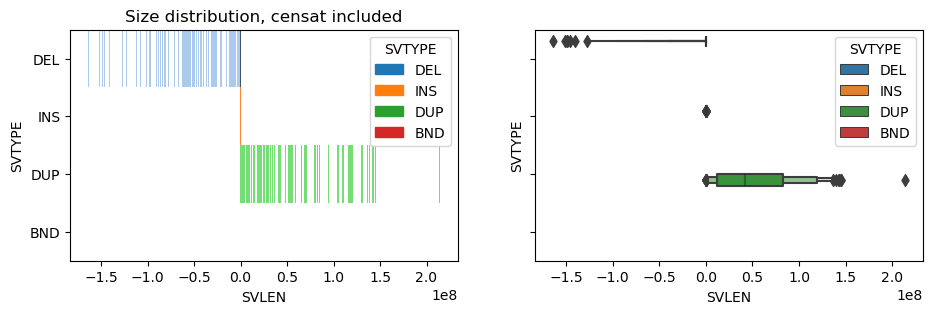

In [6]:
fig, ax = plt.subplots(ncols = 2, figsize = (11, 3), sharey = True)

sns.set_color_codes("muted")
sns.histplot(ax = ax[0], data = simulation_0823, x = 'SVLEN', y = 'SVTYPE', hue = 'SVTYPE', binwidth = 1000000)
sns.boxenplot(ax = ax[1], data= simulation_0823, x = 'SVLEN', y = 'SVTYPE', hue = 'SVTYPE')
ax[0].set_title("Size distribution, censat included")

## `bedtools` removal* of censat regions
Okay, guess we're going to need to do `bedtools intersect`, starting from the original `sniffles` output vcf.

(I tried `bedtools subtract` but it didn't actually do anything. I must have used it wrong?)

```
bedtools intersect -v -a output/mapping/CHM13/sniffles/mosaic/single_sample/HG002_894_simulation.vcf.gz -b ../references/T2T_CHM13/T2T_CHM13_censat.bed > output/mapping/CHM13/bedtools/20230907_simulation_censat_subtract.tsv
```

I can implement this as a `snakemake` rule if this ends up being the way I want to go for short-term future analyses.

Below, reading in `20230907_simulation_censat_subtract.tsv` as `simulation_subtract`, then applying filters...

In [7]:
simulation_subtract = parse.subtract_table('/Users/stacyli/savio/global/scratch/stacy-l/spermSV/output/mapping/CHM13/bedtools/20230907_simulation_censat_subtract.tsv')
simulation_subtract

,#CHROM,chromStart,chromEnd,SVTYPE,SVLEN,ID,REF,ALT,QUAL,FILTER,INFO,ORIGIN,RNAMES,GT,GQ,DR,DV
0,chr1,36605.0,36605.0,INS,876.0,Sniffles2.INS.BS0,N,GGCGGCACACGCGGGTTCTCTGTGGCCAGCAGGCGGCGCTGCAGGA...,57,PASS,IMPRECISE;MOSAIC;SVTYPE=INS;SVLEN=876;END=3660...,894,"894/227216994/ccs,894/206902104/ccs,894/176952...",0/1,12,71,21
1,chr1,90774.0,90774.0,INS,76.0,Sniffles2.INS.DS0,N,GGGGTAGGAGACCATCAGGACAAACACGTGGATACATGGAGGGGAA...,60,PASS,IMPRECISE;MOSAIC;SVTYPE=INS;SVLEN=76;END=90774...,894,"894/232981007/ccs,894/49681026/ccs",0/0,21,15,2
2,chr1,92624.0,92701.0,DEL,-77.0,Sniffles2.DEL.1871S0,accatcaggacaaacacgtgggtacatggaggggaacaacacacac...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-77;END=92701;...,894,894/34931686/ccs,0/0,34,16,1
3,chr1,93068.0,93144.0,DEL,-76.0,Sniffles2.DEL.1873S0,ggggacagggggtaggagaccatcaggacaaacacgtggatacatg...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-76;END=93144;...,894,894/34931686/ccs,0/0,34,16,1
4,chr1,215586.0,215638.0,DEL,-52.0,Sniffles2.DEL.1878S0,gcaatggaatgcattggaatggaatgcaatggacttgaatgggatg...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-52;END=215638...,894,894/148115362/ccs,0/0,60,53,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10198,chr21,44566612.0,44566721.0,DEL,-109.0,Sniffles2.DEL.FE2S17,CAACCCAGTGGGCCGGCCACACCTCCAGCCCTGTGACGGGCACCCA...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-109;END=44566...,894,"894/19007495/ccs,894/156896961/ccs,894/1492258...",0/0,60,35,3
10199,chr21,44583943.0,44584079.0,DEL,-136.0,Sniffles2.DEL.FE5S17,AGGTCATGAAGCCCTGAGGGTAGAGCCTGGATCACGTGGGAGGACA...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-136;END=44584...,894,894/109842709/ccs,0/0,60,45,1
10200,chr21,44789694.0,44789694.0,INS,112.0,Sniffles2.INS.613S17,N,TGTGTGGTGCCCACGCGGCGCGTGATTGGTGAATGAACACAGCGTG...,60,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=112;END=447896...,894,894/125113905/ccs,0/0,60,28,1
10201,chr21,44790274.0,44790274.0,INS,117.0,Sniffles2.INS.617S17,N,TGTGTGTGTGTGGTGCCCACGTGGCGCGTGCTCGGTGAATGAACAC...,60,PASS,PRECISE;MOSAIC;SVTYPE=INS;SVLEN=117;END=447902...,894,894/95622574/ccs,0/0,60,26,1


Now, filter down and compare aspects of below `subtract_filtered` (vcf -> censat subtract, filtered) and `simulation_0823` (just vcf -> filtered, from last notebook).

In [8]:
subtract_filtered = simulation_subtract.query("DV == 1 & DR >= 30 & DR <= 70 & QUAL >= 50")
subtract_filtered

,#CHROM,chromStart,chromEnd,SVTYPE,SVLEN,ID,REF,ALT,QUAL,FILTER,INFO,ORIGIN,RNAMES,GT,GQ,DR,DV
4,chr1,215586.0,215638.0,DEL,-52.0,Sniffles2.DEL.1878S0,gcaatggaatgcattggaatggaatgcaatggacttgaatgggatg...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-52;END=215638...,894,894/148115362/ccs,0/0,60,53,1
5,chr1,218571.0,218642.0,DEL,-71.0,Sniffles2.DEL.1879S0,tcgaaaggaatggaatggaatggaatggaatggaatggaatggaat...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-71;END=218642...,894,894/134088549/ccs,0/0,60,51,1
6,chr1,218804.0,218870.0,DEL,-66.0,Sniffles2.DEL.187AS0,aatggaatcgacccgaatggaatggaatggaatggaatggaatgga...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-66;END=218870...,894,894/134088549/ccs,0/0,60,51,1
7,chr1,219836.0,219907.0,DEL,-71.0,Sniffles2.DEL.187BS0,aatggaatgaacccgaatggaatggaatggaatggaatggaatgga...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-71;END=219907...,894,894/206832977/ccs,0/0,60,52,1
8,chr1,267875.0,268034.0,DEL,-159.0,Sniffles2.DEL.187DS0,tctaataaggaatatcaataaagaaataaaaattattttaaaaaac...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-159;END=26803...,894,894/142739248/ccs,0/0,60,65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10192,chr21,44423383.0,44423498.0,DEL,-115.0,Sniffles2.DEL.FC5S17,TTTTGGGGTGACGGATTTTACTGATGGTATGAGGGATTTTTTGGGG...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-115;END=44423...,894,894/84479997/ccs,0/0,60,31,1
10194,chr21,44469282.0,44469348.0,DEL,-66.0,Sniffles2.DEL.FCFS17,gatggtgatgatggtggtgatgatggtgaaggtggtgatggtggtg...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-66;END=444693...,894,894/88740877/ccs,0/0,60,37,1
10197,chr21,44559692.0,44559748.0,DEL,-56.0,Sniffles2.DEL.FDDS17,atcagccgggagcagtggctcatgcctgtaatcccagtactttggg...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-56;END=445597...,894,894/254219044/ccs,0/0,60,31,1
10199,chr21,44583943.0,44584079.0,DEL,-136.0,Sniffles2.DEL.FE5S17,AGGTCATGAAGCCCTGAGGGTAGAGCCTGGATCACGTGGGAGGACA...,N,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-136;END=44584...,894,894/109842709/ccs,0/0,60,45,1


### Examining variants after censat removal

First, a little peek at whether or not that changed much...

In [9]:
# Filtered, but censat region not excluded
print("Censat regions not excluded")
print('Max:', simulation_0823['SVLEN'].max())
print('Min:', simulation_0823['SVLEN'].min())
print('Mean:', np.nanmean(simulation_0823['SVLEN']))
print('Standard deviation:', np.nanstd(simulation_0823['SVLEN']))
print('Median:', np.nanmedian(simulation_0823['SVLEN']))

# Filtered and censat region excluded
print("\nCensat regions excluded")
print('Max:', subtract_filtered['SVLEN'].max())
print('Min:', subtract_filtered['SVLEN'].min())
print('Mean:', np.nanmean(subtract_filtered['SVLEN']))
print('Standard deviation:', np.nanstd(subtract_filtered['SVLEN']))
print('Median:', np.nanmedian(subtract_filtered['SVLEN']))

Censat regions not excluded
Max: 213647998.0
Min: -164587816.0
Mean: 127398.53353867214
Standard deviation: 10667629.329853574
Median: -65.0

Censat regions excluded
Max: 116507891.0
Min: -123491287.0
Mean: 30909.825554178715
Standard deviation: 5226681.121381584
Median: -65.0


Well, it's better, but not GREAT. Let's ~ manually examine ~ things.

In [10]:
# What's the average size by group?
print('Median values of SVLEN\n', subtract_filtered.groupby('SVTYPE')['SVLEN'].median())
print('\nMean values of SVLEN\n', subtract_filtered.groupby('SVTYPE')['SVLEN'].mean())
print('\nStdev of values of SVLEN\n', subtract_filtered.groupby('SVTYPE')['SVLEN'].std())

Median values of SVLEN
 SVTYPE
BND           NaN
DEL         -76.0
DUP    18724659.5
INS          90.0
Name: SVLEN, dtype: float64

Mean values of SVLEN
 SVTYPE
BND             NaN
DEL   -3.030562e+05
DUP    2.791156e+07
INS    1.740664e+02
Name: SVLEN, dtype: float64

Stdev of values of SVLEN
 SVTYPE
BND             NaN
DEL    3.899017e+06
DUP    3.017083e+07
INS    2.248034e+02
Name: SVLEN, dtype: float64


Clearly, there's a ton of skew, and duplications are the major source of "hmm that looks like it might not be real"-type SV lengths.

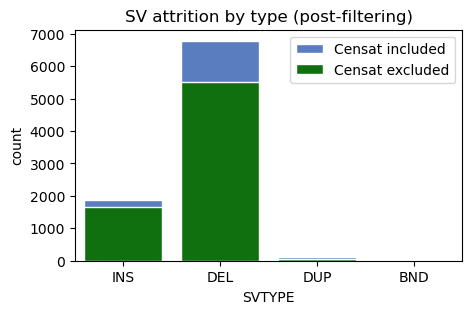

In [11]:
fig, ax = plt.subplots(figsize = (5, 3))
sns.countplot(ax=ax, data=simulation_0823, x = 'SVTYPE',
            label="Censat included", color = 'b', edgecolor = 'white',
            order = ["INS", "DEL", "DUP", "BND"])
sns.countplot(ax=ax, data=subtract_filtered, x = 'SVTYPE',
            label="Censat excluded", color = 'green', edgecolor = 'white',
            order = ["INS", "DEL", "DUP", "BND"])
ax.set_title("SV attrition by type (post-filtering)")
ax.legend()

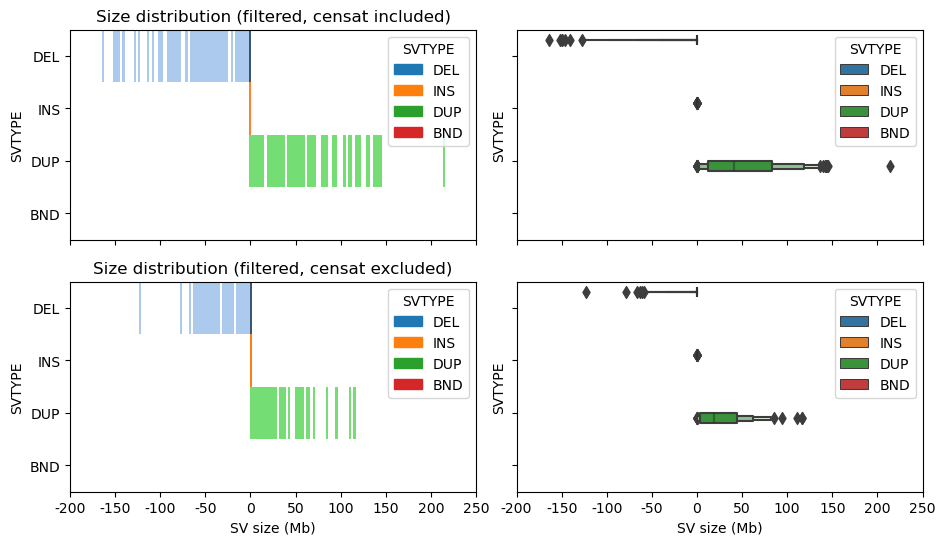

In [12]:
# huh that actually kind of worked out better than I thought it would
# still very ugly but meh
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (11, 6), sharey = True, sharex = True)

sns.set_color_codes("muted")
sns.histplot(ax = ax[0,0], data = simulation_0823, x = 'SVLEN', y = 'SVTYPE', hue = 'SVTYPE', binwidth = 2500000)
sns.boxenplot(ax = ax[0,1], data= simulation_0823, x = 'SVLEN', y = 'SVTYPE', hue = 'SVTYPE')
sns.histplot(ax = ax[1,0], data = subtract_filtered, x = 'SVLEN', y = 'SVTYPE', hue = 'SVTYPE', binwidth = 2500000)
sns.boxenplot(ax = ax[1,1], data= subtract_filtered, x = 'SVLEN', y = 'SVTYPE', hue = 'SVTYPE')

plt.xticks(ticks = ax[0,0].get_xticks(), labels = ['-200', '-150', '-100', '-50', '0', '50', '100', '150', '200', '250'])
ax[0,1].set_xlabel('')
ax[1,0].set_xlabel('SV size (Mb)')
ax[1,1].set_xlabel('SV size (Mb)')

ax[0,0].set_title("Size distribution (filtered, censat included)")
ax[1,0].set_title("Size distribution (filtered, censat excluded)")
fig.subplots_adjust(wspace = 0.1, hspace = 0.2)

### Examining largest calls

These are almost guaranteed to be false calls, but it might be useful to learn if they cluster somehow (can be filtered).

In [13]:
subtract_filtered.sort_values('SVLEN', ascending = False).head(10)

,#CHROM,chromStart,chromEnd,SVTYPE,SVLEN,ID,REF,ALT,QUAL,FILTER,INFO,ORIGIN,RNAMES,GT,GQ,DR,DV
1278,chr2,118313239.0,234821130.0,DUP,116507891.0,Sniffles2.DUP.1A0ES1,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=116507891;END=...,894,894/72483853/ccs,0/0,60,44,1
2437,chr4,73998621.0,189861221.0,DUP,115862600.0,Sniffles2.DUP.1644S3,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=115862600;END=...,894,894/146146701/ccs,0/0,60,47,1
2408,chr4,67163939.0,178195801.0,DUP,111031862.0,Sniffles2.DUP.163DS3,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=111031862;END=...,894,894/76945243/ccs,0/0,60,60,1
3065,chr5,68522633.0,162941637.0,DUP,94419004.0,Sniffles2.DUP.14F3S4,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=94419004;END=1...,894,894/146609086/ccs,0/0,60,68,1
3109,chr5,81815637.0,166684933.0,DUP,84869296.0,Sniffles2.DUP.14FDS4,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=84869296;END=1...,894,894/27857265/ccs,0/0,60,49,1
4259,chr7,88063271.0,157718750.0,DUP,69655479.0,Sniffles2.DUP.1061S6,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=69655479;END=1...,894,894/193401816/ccs,0/0,60,52,1
2416,chr4,69675087.0,135848645.0,DUP,66173558.0,Sniffles2.DUP.1640S3,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=66173558;END=1...,894,894/85394170/ccs,0/0,60,51,1
2505,chr4,98752026.0,164703886.0,DUP,65951860.0,Sniffles2.DUP.1654S3,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=65951860;END=1...,894,894/173016466/ccs,0/0,60,62,1
3734,chr6,96813504.0,160688376.0,DUP,63874872.0,Sniffles2.DUP.C43S5,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=63874872;END=1...,894,894/150864827/ccs,0/0,60,50,1
7237,chr13,34668152.0,93201935.0,DUP,58533783.0,Sniffles2.DUP.1A39SD,N,<DUP>,60,PASS,PRECISE;MOSAIC;SVTYPE=DUP;SVLEN=58533783;END=9...,894,894/3277266/ccs,0/0,60,53,1


Unsurprisingly, the top large hits are (by index value):
* [1278](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr2%3A118313239%2D118813239&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Sort of close-ish to a centromere, but not categorized as pericentromeric.
* [2437](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr4%3A73998621%2D74498621&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Again, sort of close-ish to a centromere, but not categorized as pericentromeric.
* [2408](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr4%3A67163939%2D67663939&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Again, sort of close to a centromere, but not categorized as pericentromeric.
* [3065](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr5%3A68522633%2D68572633&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Samesies.
* [3109](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr5%3A81815637%2D81865637&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Well, a bit further, but still on the proximal quarter to the centromere...
* [4259](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr7%3A88063271%2D88113271&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Again.
* [2416](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr4%3A69675087%2D69725087&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Yup.
* [2505](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr4%3A98752026%2D98802026&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Wow, this one made it out to the proximal 1/3rd. 
* [3734](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr6%3A96813504%2D96863504&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Also the same deal, proximal third.
* [7237](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr13%3A34668152%2D34718152&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Same, proximal third.

They're likely all derived from `894` as a matter of `894` being the majority of this simulation.

Sort of a weird trend here, but sort of corresponds to Joana's ideogram of her SV findings (bot those were mostly immediately pericentromeric/centromeric and peritelomeric/telomeric... I mean, I did take them out of here I guess, but still, no peaks in the proximal quarterish region?) 

Are there certain locations more prone to bad single-read supported calls? (How do we know these are not real???) 

Would be easier to visualize on an chromosome ideogram (but also... I have to switch to R for that........)


In [14]:
# let's see about the largest (negative, deletion) values...
subtract_filtered.sort_values('SVLEN', ascending = True).head(10)

,#CHROM,chromStart,chromEnd,SVTYPE,SVLEN,ID,REF,ALT,QUAL,FILTER,INFO,ORIGIN,RNAMES,GT,GQ,DR,DV
1233,chr2,105142138.0,228633425.0,DEL,-123491287.0,Sniffles2.DEL.184BS1,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-123491287;END...,894,894/12784489/ccs,0/0,60,63,1
1958,chr3,115623471.0,193956176.0,DEL,-78332705.0,Sniffles2.DEL.1789S2,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-78332705;END=...,894,894/217580507/ccs,0/0,60,55,1
3142,chr5,93957707.0,160997188.0,DEL,-67039481.0,Sniffles2.DEL.137BS4,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-67039481;END=...,894,894/163056160/ccs,0/0,60,47,1
3637,chr6,66389243.0,129419960.0,DEL,-63030717.0,Sniffles2.DEL.96CS5,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-63030717;END=...,894,894/155910857/ccs,0/0,60,60,1
3081,chr5,71897085.0,132867062.0,DEL,-60969977.0,Sniffles2.DEL.12BAS4,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-60969977;END=...,894,894/248775447/ccs,0/0,60,59,1
7256,chr13,40557403.0,99721074.0,DEL,-59163671.0,Sniffles2.DEL.18E8SD,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-59163671;END=...,894,894/166135870/ccs,0/0,60,48,1
7591,chr14,22970420.0,80172189.0,DEL,-57201769.0,Sniffles2.DEL.BFDSE,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-57201769;END=...,894,894/149883097/ccs,0/0,60,49,1
7229,chr13,32960344.0,88962440.0,DEL,-56002096.0,Sniffles2.DEL.189ESD,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-56002096;END=...,894,894/131074891/ccs,0/0,60,48,1
7253,chr13,37637968.0,92905884.0,DEL,-55267916.0,Sniffles2.DEL.18BASD,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-55267916;END=...,894,894/132517914/ccs,0/0,60,59,1
2597,chr4,132375793.0,186466548.0,DEL,-54090755.0,Sniffles2.DEL.14DDS3,N,<DEL>,60,PASS,PRECISE;MOSAIC;SVTYPE=DEL;SVLEN=-54090755;END=...,894,894/54006613/ccs,0/0,60,52,1


Again, same deal, examining the top 10 hits manually.
* [1233](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr2%3A105142138%2D105192138&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Very close to centromere, but not marked pericentromeric.
* [1958](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr3%3A115623471%2D115673471&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Yes.
* [3142](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr5%3A93957707%2D94057707&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Proximal third.
* [3637](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr6%3A66389243%2D66439243&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Sooooo close.
* [3081](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr5%3A71897085%2D71947085&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Proximal quarter.
* [7256](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr13%3A40557403%2D40607403&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Proximal third, borderline quarter.
* [7591](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr14%3A22970420%2D23020420&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Proximal quarter, quite close.
* [7229](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr13%3A32960344%2D33010344&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Proximal quarter.
* [7253](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr13%3A37637968%2D37687968&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Proximal third, borderline quarter.
* [2597](https://genome.ucsc.edu/cgi-bin/hgTracks?db=hub_3671779_hs1&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr4%3A132375793%2D132425793&hgsid=1704035068_aLr46zVrMkRC9rOSN71JqMbSeqaa): Oh, RARE, this one is in almost exactly half of the right arm.

Actually, now that I think of it, all of these were found in the "right arm" as shown on UCSC. Probably because they usually orient the longer arm of both chromosome structure types on the right side.

Well, I guess excluding censat regions did remove a lot of the extreme values, but not necessarily the most...

Semi-unsurprisingly, most of these large questionable SVs are `DEL`/`DUP`. Let's zoom in on `INS`...

Text(0.5, 1.0, 'Length of insertions post-filtering & censat exclusion')

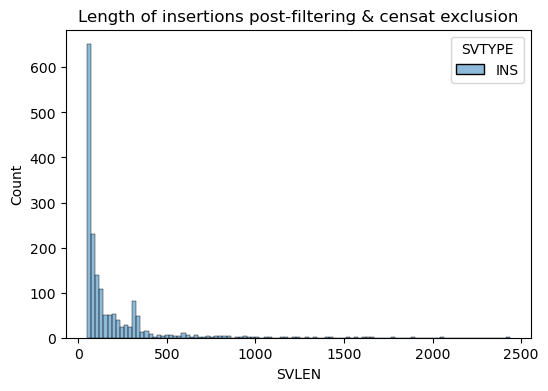

In [15]:
sns.set_color_codes("muted")
plt.figure(figsize = (6,4))
sns.histplot(data = subtract_filtered.query("SVTYPE == 'INS'"), x = 'SVLEN', hue = 'SVTYPE')
plt.title("Length of insertions post-filtering & censat exclusion")

Text(0.5, 1.0, 'Length of deletions post-filtering & censat exclusion')

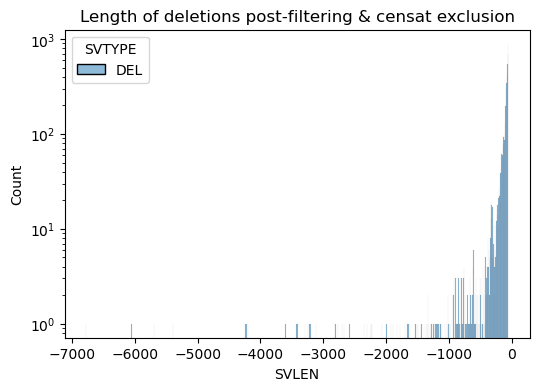

In [16]:
sns.set_color_codes("muted")
plt.figure(figsize = (6,4))
sns.histplot(data = subtract_filtered.query("SVTYPE == 'DEL' & SVLEN > -10000"), x = 'SVLEN', hue = 'SVTYPE')
plt.yscale('log')
plt.title("Length of deletions post-filtering & censat exclusion")

Much more reasonable! Although I've no idea if this is real either.

I should plot this by sample...

Text(0.5, 1.0, 'Length of insertions post-filtering & censat exclusion')

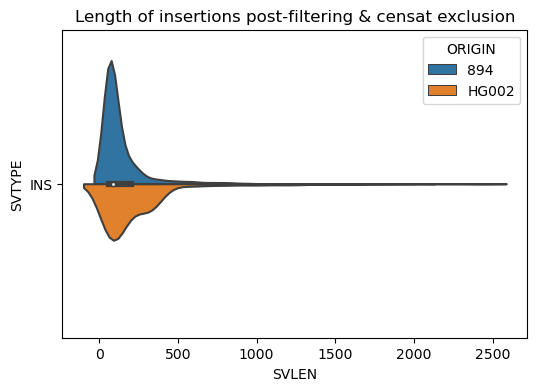

In [19]:
# only insertions

sns.set_color_codes("muted")
plt.figure(figsize = (6,4))
sns.violinplot(data = subtract_filtered.query("SVTYPE == 'INS'"), x = 'SVLEN', y = 'SVTYPE', hue = 'ORIGIN', split = True)
plt.title("Length of insertions post-filtering & censat exclusion")

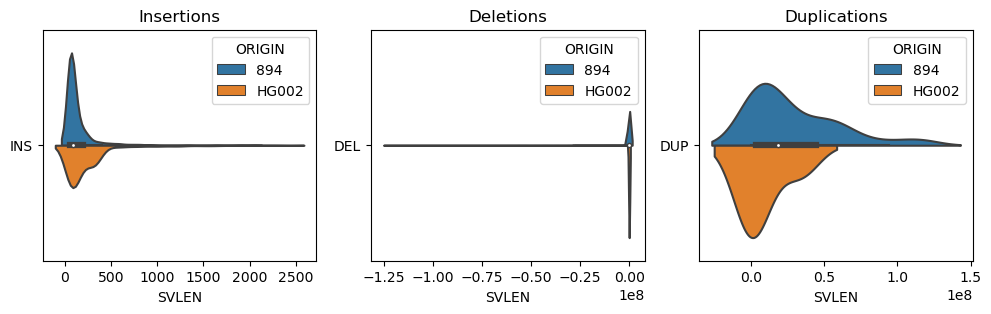

In [21]:
# all categories (just to be thorough)

fig, ax = plt.subplots(ncols = 3, figsize = (12, 3))
sns.violinplot(ax = ax[0], data = subtract_filtered.query("SVTYPE == 'INS'"), x = "SVLEN", y = "SVTYPE", hue = "ORIGIN", split = True)
sns.violinplot(ax = ax[1], data = subtract_filtered.query("SVTYPE == 'DEL'"), x = "SVLEN", y = "SVTYPE", hue = "ORIGIN", split = True)
sns.violinplot(ax = ax[2], data = subtract_filtered.query("SVTYPE == 'DUP'"), x = "SVLEN", y = "SVTYPE", hue = "ORIGIN", split = True)
# this doesn't play well for BND :( 
# sns.violinplot(ax = ax[3], data = simulation_subtract.query("SVTYPE == 'BND'"), x = "SVLEN", y = "SVTYPE", hue = "ORIGIN", split = True)

sns.set_color_codes("muted")
ax[0].set_ylabel("")
ax[1].set_ylabel("")
ax[2].set_ylabel("")
ax[0].set_title("Insertions")
ax[1].set_title("Deletions")
ax[2].set_title("Duplications")


fig.subplots_adjust(wspace = 0.2)

Above probably doesn't say much – after all, `HG002` is spiked in at 1X. Just one data point, maybe worth noting that a size profile is interesting, and maybe worth examining when considering `HG002` benchmark calls.

## `HG002` benchmark comparison

Pulling from the [GIAB HG002 benchmark repository](https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/AshkenazimTrio/HG002_NA24385_son/), saving to `/global/scratch/users/stacy-l/spermSV/benchmarks/HG002`. 

* `HG002_GRCh38_1_22_v4.2.1_benchmark.vcf.gz` - [link](https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/AshkenazimTrio/HG002_NA24385_son/latest/GRCh38/): On `GRCh38`.
* `HG002_SVs_Tier1_noVDJorXorY_v0.6.2.bed` [link](https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/AshkenazimTrio/HG002_NA24385_son/NIST_SV_v0.6/): On `GRCh38`.
* `HG002_SVs_Tier1_v0.6.vcf.gz` - [link](https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/AshkenazimTrio/HG002_NA24385_son/NIST_SV_v0.6/): On `GRCh37` (hg19??? hwy)
* `HG002_GRCh38_CMRG_SV_v1.00.bed` - [link](https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/AshkenazimTrio/HG002_NA24385_son/CMRG_v1.00/): On `GRCh37`.  (hg19??? hwy)

I have to lift over the coords. (VERY FUN!)

### Running various lift-overs


Download the chain file(s) from the [UCSC repository](http://hgdownload.soe.ucsc.edu/goldenPath/hs1/liftOver/), spec. the file `hg38-chm13v2.over.chain.gz` & `hg19-chm13v2.over.chain.gz` and download to `/global/scratch/users/stacy-l/references/T2T_CHM13/*`. (The naming convention of these files is... not good. I thought `hs1` == `CHM13v2`??????)

Using the env at `envs/liftover.yml`.
```
# prepend chrs on the SV Tier 1 callset VCFs & bedfiles to make chain file compatible (because for some reason, neither the VCF nor bedfiles for Tier 1 SVs had chr prefixes on chromosome names...)
sed -e 's#^#chr#;' benchmarks/HG002/HG002_SVs_Tier1_noVDJorXorY_v0.6.2.bed > benchmarks/HG002/HG002_SVs_Tier1_noVDJorXorY_v0.6.2_withChr.bed
zcat benchmarks/HG002/HG002_SVs_Tier1_v0.6.vcf.gz | sed -e 's#^#chr#;' - > benchmarks/HG002/HG002_SVs_Tier1_v0.6_withChr.vcf
sed -i 's/chr#CHROM/#CHROM/g' benchmarks/HG002/HG002_SVs_Tier1_v0.6_withChr.vcf
sed -i 's/chr##/##/g' benchmarks/HG002/HG002_SVs_Tier1_v0.6_withChr.vcf
bgzip -@ 40 benchmarks/HG002/HG002_SVs_Tier1_v0.6_withChr.vcf

# run liftovervcf because svpop doesn't like regular bedfiles :)
# also, it has a useful output summary log at the end describing the # success per contig
mkdir -p benchmarks/HG002/liftovervcf
picard CreateSequenceDictionary -R ../references/T2T_CHM13/hs1.fa -O ../references/T2T_CHM13/hs1.dict 
picard LiftoverVcf -Xmx10G -I benchmarks/HG002/HG002_GRCh38_1_22_v4.2.1_benchmark.vcf.gz -O benchmarks/HG002/liftovervcf/HG002_CHM13_1_22_v4.2.1_benchmark.vcf.gz -C ../references/T2T_CHM13/hg38-chm13v2.over.chain.gz -R ../references/T2T_CHM13/hs1.fa --REJECT benchmarks/HG002/liftovervcf/unmapped_HG002_CHM13_1_22_v4.2.1_benchmark.vcf.gz &> benchmarks/HG002/liftovervcf/logs/HG002_CHM13_1_22_v4.2.1_benchmark.log
picard LiftoverVcf -Xmx10G -I benchmarks/HG002/HG002_SVs_Tier1_v0.6_withChr.vcf.gz -O benchmarks/HG002/liftovervcf/HG002_CHM13_SVs_Tier1_v0.6_withChr.vcf.gz -C ../references/T2T_CHM13/hg19-chm13v2.over.chain.gz -R ../references/T2T_CHM13/hs1.fa --REJECT benchmarks/HG002/liftovervcf/unmapped_HG002_CHM13_SVs_Tier1_v0.6_withChr.vcf.gz &> benchmarks/HG002/liftovervcf/logs/HG002_CHM13_SVs_Tier1_v0.6_withChr.log
picard LiftoverVcf -Xmx10G -I benchmarks/HG002/HG002_GRCh38_CMRG_SV_v1.00.vcf.gz -O benchmarks/HG002/liftovervcf/HG002_CHM13_CMRG_SV_v1.00.vcf.gz -C ../references/T2T_CHM13/hg38-chm13v2.over.chain.gz -R ../references/T2T_CHM13/hs1.fa --REJECT benchmarks/HG002/liftovervcf/unmapped_HG002_CHM13_CMRG_SV_v1.00.vcf.gz  &> benchmarks/HG002/liftovervcf/logs/HG002_CHM13_CMRG_SV_v1.00.log

# also use the standard vcf -> bed -> liftover protocol anyways, because bedfiles are useful too
./vcfToBed ../../spermSV/benchmarks/HG002/HG002_GRCh38_1_22_v4.2.1_benchmark.vcf.gz ../../spermSV/benchmarks/HG002/HG002_GRCh38_1_22_v4.2.1_benchmark
./vcfToBed ../../spermSV/benchmarks/HG002/HG002_SVs_Tier1_v0.6_withChr.vcf.gz ../../spermSV/benchmarks/HG002/HG002_SVs_Tier1_v0.6_withChr

# liftover of available bedfiles (where Tier 1 SVs w/o VDJ/chrX/chrY were *only* available as bedfile)
liftOver benchmarks/HG002/HG002_SVs_Tier1_noVDJorXorY_v0.6.2_withChr.bed ../references/T2T_CHM13/hg19-chm13v2.over.chain.gz benchmarks/HG002/liftover/HG002_CHM13_SVs_Tier1_noVDJorXorY_v0.6.2_withChr.bed benchmarks/HG002/liftover/unmapped_HG002_CHM13_SVs_Tier1_noVDJorXorY_v0.6.2_withChr.bed
liftOver benchmarks/HG002/HG002_GRCh38_CMRG_SV_v1.00.bed ../references/T2T_CHM13/hg38-chm13v2.over.chain.gz benchmarks/HG002/liftover/HG002_CHM13_CMRG_SV_v1.00.bed benchmarks/HG002/liftover/unmapped_HG002_CHM13_CMRG_SV_v1.00.bed

# liftover of converted bedfiles
liftOver -bedPlus=9 benchmarks/HG002/HG002_GRCh38_1_22_v4.2.1_benchmark.bed ../references/T2T_CHM13/hg38-chm13v2.over.chain.gz benchmarks/HG002/liftover/HG002_CHM13_1_22_v4.2.1_benchmark_converted.bed benchmarks/HG002/liftover/unmapped_HG002_CHM13_1_22_v4.2.1_benchmark_converted.bed
liftOver -bedPlus=9 benchmarks/HG002/HG002_SVs_Tier1_v0.6_withChr.bed ../references/T2T_CHM13/hg19-chm13v2.over.chain.gz benchmarks/HG002/liftover/HG002_CHM13_SVs_Tier1_v0.6_withChr.bed benchmarks/HG002/liftover/unmapped_HG002_CHM13_SVs_Tier1_v0.6_withChr.bed
```



After a lot of hemming and hawing, it's actually easier for me to intersect the raw simulation VCF with the benchmark bedfile and then filter again, so that's what we're doing. This is plenty enough for one notebook: let's try to open a new one now.